In [41]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


## FDM Simulation

In [98]:
import numpy as np
import time


class FreezingSoilFDM:
    """
    1D finite difference forward model for soil freezing/thawing processes.
    Constitutive relations and latent heat treatment are aligned as closely as possible
    with the current PINN implementation.
    """

    def __init__(self, params):
        # ----- Physical parameters -----
        self.L = params['L']                    # Latent heat of phase change (MJ/m^3)
        self.C_i = params['C_i']                # Specific heat of ice (MJ/(m^3·K))
        self.C_l = params['C_l']                # Specific heat of liquid water (MJ/(m^3·K))
        self.C_f = params['C_f']                # Specific heat of soil skeleton (MJ/(m^3·K))
        self.lambda_i = params['lambda_i']      # Thermal conductivity of ice (MJ/(day·m·K))
        self.lambda_l = params['lambda_l']      # Thermal conductivity of liquid water
        self.lambda_f = params['lambda_f']      # Thermal conductivity of soil skeleton
        self.eta = params['eta']                # Porosity
        self.b = params['b']                    # Parameter for unfrozen water curve
        self.T_nabla = params['T_nabla']        # Freezing point depression onset (°C)

        # ----- Parameters to match PINN phi(T) -----
        self.k_phi = params.get('k_phi', 8.0)       # Same as PINN
        self.eps_phi = params.get('eps_phi', 1e-6)  # Same as PINN

        # ----- Numerical parameters -----
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None
        self.x = None
        self.t = None
        self.T_field = None

    # ------------------------------------------------------------------
    # Constitutive relations aligned with PINN
    # ------------------------------------------------------------------
    def pore_water_content(self, T):
        """
        Pore liquid water fraction phi(T), aligned with the PINN:

            T_abs = abs(T).clamp(min=eps)
            step = sigmoid(k * (T - T_nabla))
            phi_low = abs(T_nabla)^b * T_abs^(-b)
            phi = step * 1 + (1 - step) * phi_low
        """
        T_abs = np.clip(np.abs(T), self.eps_phi, None)
        step = 1.0 / (1.0 + np.exp(-self.k_phi * (T - self.T_nabla)))
        phi_low = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi = step * 1.0 + (1.0 - step) * phi_low
        return phi

    def unfrozen_water_content(self, T):
        """Volumetric unfrozen water content theta = eta * phi(T)"""
        return self.eta * self.pore_water_content(T)

    def effective_heat_capacity(self, T):
        """Effective volumetric heat capacity C_eff"""
        phi = self.pore_water_content(T)
        return (1.0 - self.eta) * self.C_f + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)

    def effective_conductivity(self, T):
        """Effective thermal conductivity lambda_eff"""
        phi = self.pore_water_content(T)
        return (1.0 - self.eta) * self.lambda_f + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)

    def dtheta_dT(self, T, h=1e-5):
        """
        Numerical derivative d(theta)/dT.
        This makes the latent heat treatment closer to the PINN formulation.
        """
        theta_plus = self.unfrozen_water_content(T + h)
        theta_minus = self.unfrozen_water_content(T - h)
        return (theta_plus - theta_minus) / (2.0 * h)

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * d(theta)/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    # ------------------------------------------------------------------
    # Boundary and initial conditions
    # ------------------------------------------------------------------
    def boundary_temperature(self, t):
        """Upper boundary (surface) temperature, unit: days, °C"""
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """Initial linear temperature profile, aligned with PINN"""
        z1, z2 = 0.0, 5.0
        T1 = self.boundary_temperature(0.0)
        T2 = 1.0
        return T1 + (T2 - T1) / (z2 - z1) * x

    # ------------------------------------------------------------------
    # Stability check for explicit solver
    # ------------------------------------------------------------------
    def check_stability(self):
        """Explicit scheme CFL condition estimate"""
        alpha_max = np.max([
            self.lambda_i / self.C_i,
            self.lambda_l / self.C_l,
            self.lambda_f / self.C_f
        ])
        dt_max = 0.5 * self.dx**2 / alpha_max
        if self.dt > dt_max:
            print(f"Warning: dt = {self.dt:.6f} > recommended max dt = {dt_max:.6f}")
            return False
        return True

    # ------------------------------------------------------------------
    # Initialization
    # ------------------------------------------------------------------
    def initialize(self, Nx=100, Nt=50000, Lx=5.0, T_total=365.0):
        """Initialize spatial grid, time grid, and temperature field"""
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / Nt

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        if not self.check_stability():
            alpha_max = np.max([
                self.lambda_i / self.C_i,
                self.lambda_l / self.C_l,
                self.lambda_f / self.C_f
            ])
            dt_safe = 0.9 * 0.5 * self.dx**2 / alpha_max
            self.Nt = int(np.ceil(T_total / dt_safe))
            self.dt = T_total / self.Nt
            self.t = np.linspace(0.0, T_total, self.Nt)
            print(f"Adjusted explicit settings: Nt = {self.Nt}, dt = {self.dt:.6f}")

        T_init = self.initial_temperature_profile(self.x)
        self.T_field = np.zeros((self.Nx, self.Nt))
        self.T_field[:, 0] = T_init

    # ------------------------------------------------------------------
    # Explicit solver with apparent heat capacity
    # ------------------------------------------------------------------
    def solve_explicit(self):
        """Explicit finite difference solver using apparent heat capacity"""
        start = time.time()
        T = self.T_field[:, 0].copy()

        for n in range(1, self.Nt):
            t_n = n * self.dt

            # Boundary conditions
            T[0] = self.boundary_temperature(t_n)
            T[-1] = 1.0

            C_app = self.apparent_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            T_new = T.copy()

            for i in range(1, self.Nx - 1):
                lam_p = 2.0 * lambda_eff[i] * lambda_eff[i + 1] / (lambda_eff[i] + lambda_eff[i + 1] + 1e-10)
                lam_m = 2.0 * lambda_eff[i] * lambda_eff[i - 1] / (lambda_eff[i] + lambda_eff[i - 1] + 1e-10)

                rhs = (lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])) / self.dx**2
                T_new[i] = T[i] + self.dt * rhs / C_app[i]

            T = T_new
            self.T_field[:, n] = T.copy()

            if n % max(1, self.Nt // 10) == 0:
                print(f"Explicit progress: {100.0 * n / self.Nt:.1f}%, elapsed {time.time() - start:.1f}s")

        print(f"Explicit solution completed, total time {time.time() - start:.1f}s")
        return self.T_field

    # ------------------------------------------------------------------
    # Implicit solver with apparent heat capacity
    # ------------------------------------------------------------------
    def solve_implicit(self):
        """Implicit finite difference solver using apparent heat capacity"""
        start = time.time()
        T = self.T_field[:, 0].copy()

        for n in range(1, self.Nt):
            t_n = n * self.dt

            C_app = self.apparent_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx))
            b = np.zeros(self.Nx)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            for i in range(1, self.Nx - 1):
                alpha = self.dt / (C_app[i] * self.dx**2)

                lam_p = 2.0 * lambda_eff[i] * lambda_eff[i + 1] / (lambda_eff[i] + lambda_eff[i + 1] + 1e-10)
                lam_m = 2.0 * lambda_eff[i] * lambda_eff[i - 1] / (lambda_eff[i] + lambda_eff[i - 1] + 1e-10)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i]     =  1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )
                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if n % max(1, self.Nt // 10) == 0:
                print(f"Implicit progress: {100.0 * n / self.Nt:.1f}%, elapsed {time.time() - start:.1f}s")

        print(f"Implicit solution completed, total time {time.time() - start:.1f}s")
        return self.T_field

    # ------------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------------
    def save_results(self, filename='fdm_results.npz'):
        """Save grid, time, field, and parameters"""
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Results saved to {filename}")


# if __name__ == "__main__":
#     params = {
#         'L': 334,
#         'C_i': 1.672,
#         'C_l': 4.18,
#         'lambda_i': 2.210e-6 * 8.64e4,
#         'lambda_l': 0.465e-6 * 8.64e4,
#         'lambda_f': 2e-6 * 8.64e4,
#         'C_f': 1.6,
#         'eta': 0.4,
#         'b': 0.7,
#         'T_nabla': -0.3,
#         'k_phi': 8.0,
#         'eps_phi': 1e-6
#     }

#     model = FreezingSoilFDM(params)

#     # You can change Nx and Nt as needed
#     model.initialize(Nx=100, Nt=50000, Lx=5.0, T_total=365.0)

#     # Recommended: implicit solver
#     T_field = model.solve_implicit()

#     # Optional: explicit solver
#     # T_field = model.solve_explicit()

#     model.save_results('fdm_results.npz')

Implicit progress: 10.0%, elapsed 4.2s
Implicit progress: 20.0%, elapsed 7.8s
Implicit progress: 30.0%, elapsed 11.4s
Implicit progress: 40.0%, elapsed 15.0s
Implicit progress: 50.0%, elapsed 18.5s
Implicit progress: 60.0%, elapsed 22.0s
Implicit progress: 70.0%, elapsed 25.9s
Implicit progress: 80.0%, elapsed 30.3s
Implicit progress: 90.0%, elapsed 34.6s
Implicit solution completed, total time 39.0s
Results saved to fdm_results.npz


#### Case for FDM

In [105]:
# -------------------- Configuration of the thermal property--------------------
params = {
    'L': 334,
    'C_i': 1.672,
    'C_l': 4.18,
    'lambda_i': 2.210e-6 * 8.64e4,
    'lambda_l': 0.465e-6 * 8.64e4,
    'lambda_f': 2e-6 * 8.64e4,
    'C_f': 1.6,
    'eta': 0.4,
    'b': 0.7,
    'T_nabla': -0.3
}

# Positions of sensing
depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0] 
# depths_of_interest = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] 

In [106]:
# -------------------- Perform forward modeling --------------------
def main():
    # 1. Create solver object
    fdm = FreezingSoilFDM(params)

    # 2. Initialize mesh (custom resolution available)
    # fdm.initialize(Nx=100, Nt=25000, Lx=5.0, T_total=180.0)
    fdm.initialize(Nx=100, Nt=50000, Lx=5.0, T_total=365.0)

    # 3. Choose solution method (implicit recommended, unconditionally stable)
    T_solution = fdm.solve_implicit()
    # T_solution = fdm.solve_explicit()
    
    # 4. (Optional) Save numerical solution
    fdm.save_results('fdm_results.npz')

    print("Forward modeling completed successfully!")
    print(T_solution.shape)
    return fdm, T_solution

In [107]:
if __name__ == "__main__":
    fdm, T = main()

Implicit progress: 10.0%, elapsed 3.6s
Implicit progress: 20.0%, elapsed 7.1s
Implicit progress: 30.0%, elapsed 10.6s
Implicit progress: 40.0%, elapsed 14.3s
Implicit progress: 50.0%, elapsed 17.8s
Implicit progress: 60.0%, elapsed 21.4s
Implicit progress: 70.0%, elapsed 24.9s
Implicit progress: 80.0%, elapsed 28.5s
Implicit progress: 90.0%, elapsed 32.0s
Implicit solution completed, total time 35.5s
Results saved to fdm_results.npz
Forward modeling completed successfully!
(100, 50000)


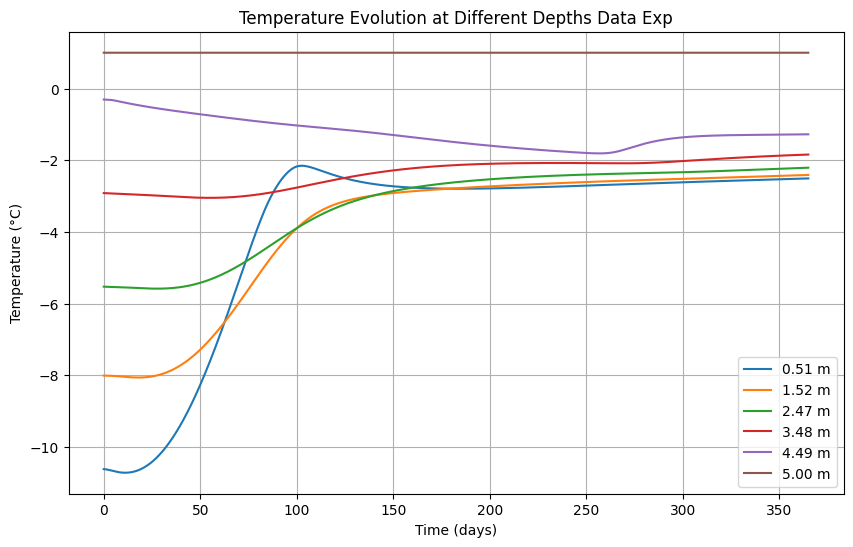

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 加载数据 ----------
data = np.load('fdm_results.npz')
x = data['x']               # 深度 (m), shape (Nx,)
t = data['t']               # 时间 (day), shape (Nt,)
T = data['T_field']         # 温度场 (°C), shape (Nx, Nt)

# ---------- 选择关注的深度（单位：米）----------
depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]   # 可自定义
# depths_of_interest = [0.5, 1.5, 2.5, 3.5, 4.5, 5.0]   # 可自定义

plt.figure(figsize=(10, 6))
for d in depths_of_interest:
    # 找到与目标深度最接近的网格索引
    idx = np.argmin(np.abs(x - d))
    actual_depth = x[idx]
    plt.plot(t, T[idx, :], label=f'{actual_depth:.2f} m')

plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Evolution at Different Depths Data Exp')
plt.legend()
plt.grid(True)
plt.show()

# PINNs

In [90]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(40)

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import RegularGridInterpolator

# -------------------- 参数配置 --------------------
params = {
    'L': 334,
    'C_i': 1.672,
    'C_l': 4.18,
    'lambda_i': 2.210e-6 * 8.64e4,
    'lambda_l': 0.465e-6 * 8.64e4,
    'lambda_f': 2e-6 * 8.64e4,
    'C_f': 1.6,
    'eta': 0.4,
    'b': 0.7,
    'T_nabla': -0.3
}

depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
x_min, x_max = 0.0, 5.0
t_min, t_max = 0.0, 365.0


# -------------------- 辅助函数 --------------------
def boundary_temperature(t):
    if isinstance(t, torch.Tensor):
        return 4.03 + 16.11 * torch.sin(2 * np.pi * t / 365.0 - 1.709)
    else:
        return 4.03 + 16.11 * np.sin(2 * np.pi * t / 365.0 - 1.709)


def initial_temperature(x):
    T0_surface = boundary_temperature(0.0)
    return T0_surface + (1.0 - T0_surface) / 5.0 * x


# -------------------- MLP 网络 --------------------
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*modules)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# -------------------- PINN 模型 --------------------
class PINN_FreezingSoil(nn.Module):
    def __init__(self, layers, params, scale=200000.0):
        super().__init__()
        self.params = params
        self.scale = scale
        self.net = MLP(layers)

        self.x_mean = (x_min + x_max) / 2.0
        self.x_std = (x_max - x_min) / 2.0
        self.t_mean = (t_min + t_max) / 2.0
        self.t_std = (t_max - t_min) / 2.0

    def forward(self, x, t):
        x_norm = (x - self.x_mean) / self.x_std
        t_norm = (t - self.t_mean) / self.t_std
        X = torch.cat([x_norm, t_norm], dim=1)
        return self.net(X)

    def phi(self, T):
        T_nabla = self.params['T_nabla']
        b = self.params['b']
        eps = 1e-6

        T_abs = torch.abs(T).clamp(min=eps)

        # Smooth switching around T_nabla
        k = 8.0
        step = torch.sigmoid(k * (T - T_nabla))

        phi_low = (abs(T_nabla) ** b) * (T_abs ** (-b))
        phi = step * 1.0 + (1.0 - step) * phi_low
        return phi

    def theta_u(self, T):
        return self.params['eta'] * self.phi(T)

    def C_eff(self, T):
        eta = self.params['eta']
        C_f = self.params['C_f']
        C_l = self.params['C_l']
        C_i = self.params['C_i']
        phi = self.phi(T)
        return (1.0 - eta) * C_f + eta * (phi * C_l + (1.0 - phi) * C_i)

    def lambda_eff(self, T):
        eta = self.params['eta']
        lambda_f = self.params['lambda_f']
        lambda_l = self.params['lambda_l']
        lambda_i = self.params['lambda_i']
        phi = self.phi(T)
        return (1.0 - eta) * lambda_f + eta * (phi * lambda_l + (1.0 - phi) * lambda_i)

    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.forward(x, t)

        T_t = torch.autograd.grad(
            T, t, grad_outputs=torch.ones_like(T),
            create_graph=True, retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x, grad_outputs=torch.ones_like(T),
            create_graph=True, retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x, grad_outputs=torch.ones_like(T_x),
            create_graph=True, retain_graph=True
        )[0]

        C = self.C_eff(T)
        lambda_ = self.lambda_eff(T)

        theta = self.theta_u(T)
        dtheta_dT = torch.autograd.grad(
            theta, T, grad_outputs=torch.ones_like(theta),
            create_graph=True, retain_graph=True
        )[0]
        dtheta_dt = dtheta_dT * T_t

        lambda_x = torch.autograd.grad(
            lambda_, x, grad_outputs=torch.ones_like(lambda_),
            create_graph=True, retain_graph=True
        )[0]

        conduction = lambda_x * T_x + lambda_ * T_xx

        L = self.params['L']
        residual = C * T_t - conduction + L * dtheta_dt

        return residual / self.scale


# -------------------- 损失函数 --------------------
def compute_loss(model, x_f, t_f, x_upper, t_upper, T_upper,
                 x_lower, t_lower, T_lower, x_ic, t_ic, T_ic,
                 w_pde, w_upper, w_lower, w_ic):
    res = model.pde_residual(x_f, t_f)
    loss_pde = torch.mean(
        torch.where(torch.abs(res) < 1.0, 0.5 * res**2, torch.abs(res) - 0.5)
    )

    T_upper_pred = model(x_upper, t_upper)
    loss_upper = torch.mean((T_upper_pred - T_upper) ** 2)

    T_lower_pred = model(x_lower, t_lower)
    loss_lower = torch.mean((T_lower_pred - T_lower) ** 2)

    T_ic_pred = model(x_ic, t_ic)
    loss_ic = torch.mean((T_ic_pred - T_ic) ** 2)

    total_loss = (
        w_pde * loss_pde +
        w_upper * loss_upper +
        w_lower * loss_lower +
        w_ic * loss_ic
    )

    return total_loss, loss_pde, loss_upper, loss_lower, loss_ic


# -------------------- 数据生成 --------------------
def generate_training_data(N_f, N_b, N_ic, device):
    t_upper = torch.rand(N_b, 1, device=device) * (t_max - t_min) + t_min
    x_upper = torch.zeros_like(t_upper)
    T_upper = boundary_temperature(t_upper)

    t_lower = torch.rand(N_b, 1, device=device) * (t_max - t_min) + t_min
    x_lower = torch.ones_like(t_lower) * x_max
    T_lower = torch.ones_like(t_lower) * 1.0

    x_ic = torch.rand(N_ic, 1, device=device) * (x_max - x_min) + x_min
    t_ic = torch.zeros_like(x_ic)
    T_ic_np = initial_temperature(x_ic.detach().cpu().numpy())
    T_ic = torch.tensor(T_ic_np, dtype=torch.float32, device=device).view(-1, 1)

    n_candidate = 100000
    x_candidate = torch.rand(n_candidate, 1, device=device) * (x_max - x_min) + x_min
    t_candidate = torch.rand(n_candidate, 1, device=device) * (t_max - t_min) + t_min

    T_estimate_np = initial_temperature(x_candidate.detach().cpu().numpy())
    T_estimate = torch.tensor(T_estimate_np, dtype=torch.float32, device=device).view(-1, 1)

    sigma = 2.0
    weight = torch.exp(-((T_estimate - params['T_nabla']) ** 2) / (2.0 * sigma ** 2))
    weight = weight.flatten()
    weight = weight / weight.sum()

    idx = torch.multinomial(weight, N_f, replacement=True)
    x_f = x_candidate[idx]
    t_f = t_candidate[idx]

    return (
        x_f, t_f,
        x_upper, t_upper, T_upper,
        x_lower, t_lower, T_lower,
        x_ic, t_ic, T_ic
    )


# -------------------- 加载 FDM 数据（仅后处理） --------------------
def load_fdm_data(filename='fdm_results.npz'):
    if not os.path.exists(filename):
        print(f"FDM data file {filename} does not exist, comparison is skipped.")
        return None, None, None

    data = np.load(filename)
    x_fdm = data['x']
    t_fdm = data['t']
    T_fdm = data['T_field']
    return x_fdm, t_fdm, T_fdm


# -------------------- 可视化对比 --------------------
def plot_comparison(model, x_plot, t_plot, T_fdm=None, save_path='pinn_vs_fdm.png'):
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        X, T = np.meshgrid(x_plot, t_plot, indexing='ij')
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).view(-1, 1)
        t_tensor = torch.tensor(T.flatten(), dtype=torch.float32, device=device).view(-1, 1)
        T_pinn = model(x_tensor, t_tensor).cpu().numpy().reshape(X.shape)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    times = [0, 90, 180, 270, 365]
    for t_val in times:
        idx_t = np.argmin(np.abs(t_plot - t_val))
        axes[0, 0].plot(x_plot, T_pinn[:, idx_t], label=f't={t_val} d (PINN)')
        if T_fdm is not None:
            axes[0, 0].plot(x_plot, T_fdm[:, idx_t], '--', label=f't={t_val} d (FDM)')
    axes[0, 0].set_xlabel('Depth (m)')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].set_title('Temperature Profiles')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    for x_val in depths_of_interest:
        idx_x = np.argmin(np.abs(x_plot - x_val))
        axes[0, 1].plot(t_plot, T_pinn[idx_x, :], label=f'x={x_val} m (PINN)')
        if T_fdm is not None:
            axes[0, 1].plot(t_plot, T_fdm[idx_x, :], '--', label=f'x={x_val} m (FDM)')
    axes[0, 1].set_xlabel('Time (days)')
    axes[0, 1].set_ylabel('Temperature (°C)')
    axes[0, 1].set_title('Temperature Evolution')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    im1 = axes[0, 2].contourf(t_plot, x_plot, T_pinn, levels=30, cmap='RdBu_r')
    axes[0, 2].contour(t_plot, x_plot, T_pinn, levels=[params['T_nabla']], colors='k', linewidths=2)
    axes[0, 2].set_xlabel('Time (days)')
    axes[0, 2].set_ylabel('Depth (m)')
    axes[0, 2].set_title('PINN Temperature Field')
    axes[0, 2].invert_yaxis()
    plt.colorbar(im1, ax=axes[0, 2])

    if T_fdm is not None:
        im2 = axes[1, 0].contourf(t_plot, x_plot, T_fdm, levels=30, cmap='RdBu_r')
        axes[1, 0].contour(t_plot, x_plot, T_fdm, levels=[params['T_nabla']], colors='k', linewidths=2)
        axes[1, 0].set_xlabel('Time (days)')
        axes[1, 0].set_ylabel('Depth (m)')
        axes[1, 0].set_title('FDM Temperature Field')
        axes[1, 0].invert_yaxis()
        plt.colorbar(im2, ax=axes[1, 0])

        error = np.abs(T_pinn - T_fdm)
        im3 = axes[1, 1].contourf(t_plot, x_plot, error, levels=30, cmap='hot')
        axes[1, 1].set_xlabel('Time (days)')
        axes[1, 1].set_ylabel('Depth (m)')
        axes[1, 1].set_title('Absolute Error |PINN - FDM|')
        axes[1, 1].invert_yaxis()
        plt.colorbar(im3, ax=axes[1, 1])

        freezing_pinn = np.zeros(len(t_plot))
        freezing_fdm = np.zeros(len(t_plot))
        for j in range(len(t_plot)):
            profile_pinn = T_pinn[:, j]
            profile_fdm = T_fdm[:, j]

            idx_pinn = np.where(profile_pinn <= params['T_nabla'])[0]
            idx_fdm = np.where(profile_fdm <= params['T_nabla'])[0]

            freezing_pinn[j] = x_plot[idx_pinn[0]] if len(idx_pinn) > 0 else x_max
            freezing_fdm[j] = x_plot[idx_fdm[0]] if len(idx_fdm) > 0 else x_max

        axes[1, 2].plot(t_plot, freezing_pinn, 'b-', label='PINN')
        axes[1, 2].plot(t_plot, freezing_fdm, 'r--', label='FDM')
        axes[1, 2].set_xlabel('Time (days)')
        axes[1, 2].set_ylabel('Freezing front depth (m)')
        axes[1, 2].set_title('Freezing Front Evolution')
        axes[1, 2].invert_yaxis()
        axes[1, 2].legend()
        axes[1, 2].grid(True)
    else:
        freezing_pinn = np.zeros(len(t_plot))
        for j in range(len(t_plot)):
            profile = T_pinn[:, j]
            idx = np.where(profile <= params['T_nabla'])[0]
            freezing_pinn[j] = x_plot[idx[0]] if len(idx) > 0 else x_max

        axes[1, 2].plot(t_plot, freezing_pinn, 'b-')
        axes[1, 2].set_xlabel('Time (days)')
        axes[1, 2].set_ylabel('Freezing front depth (m)')
        axes[1, 2].set_title('Freezing Front Evolution (PINN)')
        axes[1, 2].invert_yaxis()
        axes[1, 2].grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


# -------------------- 主训练函数 --------------------
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    layers = [2, 128, 128, 128, 1]
    scale = 200000.0
    model = PINN_FreezingSoil(layers, params, scale=scale).to(device)

    N_f = 20000
    N_b = 1000
    N_ic = 1000

    (x_f, t_f, x_upper, t_upper, T_upper,
     x_lower, t_lower, T_lower, x_ic, t_ic, T_ic) = generate_training_data(
        N_f, N_b, N_ic, device
    )

    w_upper = 1.0
    w_lower = 1.0
    w_ic = 1.0

    w_pde = 0.0
    target_w_pde = 1e4
    stage_steps = 10000
    factor = 10.0

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2000, min_lr=1e-6
    )

    n_epochs = 500000
    print("Start Adam training with gradually increased PDE weight...")

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        loss, loss_pde, loss_upper, loss_lower, loss_ic = compute_loss(
            model, x_f, t_f,
            x_upper, t_upper, T_upper,
            x_lower, t_lower, T_lower,
            x_ic, t_ic, T_ic,
            w_pde=w_pde, w_upper=w_upper, w_lower=w_lower, w_ic=w_ic
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        if (epoch + 1) % stage_steps == 0:
            if w_pde == 0.0:
                w_pde = 1e-4
                print(f">>> Stage {(epoch + 1) // stage_steps}: PDE weight initialized to {w_pde:.2e}")
            elif w_pde < target_w_pde:
                w_pde = min(w_pde * factor, target_w_pde)
                print(f">>> Stage {(epoch + 1) // stage_steps}: PDE weight increased to {w_pde:.2e}")

        if epoch % 1000 == 0:
            print(
                f"Epoch {epoch:6d}, "
                f"Total: {loss.item():.3e}, "
                f"PDE: {loss_pde.item():.3e}, "
                f"Upper: {loss_upper.item():.3e}, "
                f"Lower: {loss_lower.item():.3e}, "
                f"IC: {loss_ic.item():.3e}, "
                f"w_pde={w_pde:.2e}"
            )

    torch.save(model.state_dict(), 'pinn_freezing_soil_mlp.pth')
    print("Model saved to pinn_freezing_soil_mlp.pth")

    x_fdm, t_fdm, T_fdm_raw = load_fdm_data('fdm_results.npz')
    T_fdm_interp = None

    x_plot = np.linspace(x_min, x_max, 100)
    t_plot = np.linspace(t_min, t_max, 365)

    if x_fdm is not None:
        interp = RegularGridInterpolator(
            (x_fdm, t_fdm), T_fdm_raw,
            bounds_error=False, fill_value=None
        )
        X, T = np.meshgrid(x_plot, t_plot, indexing='ij')
        T_fdm_interp = interp((X, T))
        print("FDM data loaded and interpolated.")

    plot_comparison(
        model, x_plot, t_plot,
        T_fdm_interp,
        save_path='pinn_vs_fdm_mlp.png'
    )

Using device: cuda
Start Adam training with gradually increased PDE weight...
Epoch      0, Total: 1.910e+02, PDE: 5.105e-05, Upper: 1.457e+02, Lower: 1.369e+00, IC: 4.395e+01, w_pde=0.00e+00
Epoch   1000, Total: 6.684e+00, PDE: 4.454e-02, Upper: 6.212e+00, Lower: 3.510e-01, IC: 1.211e-01, w_pde=0.00e+00
Epoch   2000, Total: 3.487e-03, PDE: 3.964e-02, Upper: 2.212e-03, Lower: 1.594e-04, IC: 1.116e-03, w_pde=0.00e+00
Epoch   3000, Total: 8.636e-04, PDE: 1.876e-06, Upper: 4.835e-04, Lower: 2.420e-05, IC: 3.559e-04, w_pde=0.00e+00
Epoch   4000, Total: 3.976e-04, PDE: 1.274e-04, Upper: 1.913e-04, Lower: 1.264e-05, IC: 1.937e-04, w_pde=0.00e+00
Epoch   5000, Total: 2.629e-04, PDE: 6.948e-07, Upper: 1.224e-04, Lower: 1.339e-05, IC: 1.271e-04, w_pde=0.00e+00
Epoch   6000, Total: 2.541e-04, PDE: 4.085e-01, Upper: 1.366e-04, Lower: 1.599e-05, IC: 1.015e-04, w_pde=0.00e+00
Epoch   7000, Total: 3.965e-04, PDE: 4.880e-06, Upper: 1.721e-04, Lower: 9.185e-05, IC: 1.325e-04, w_pde=0.00e+00
Epoch   80

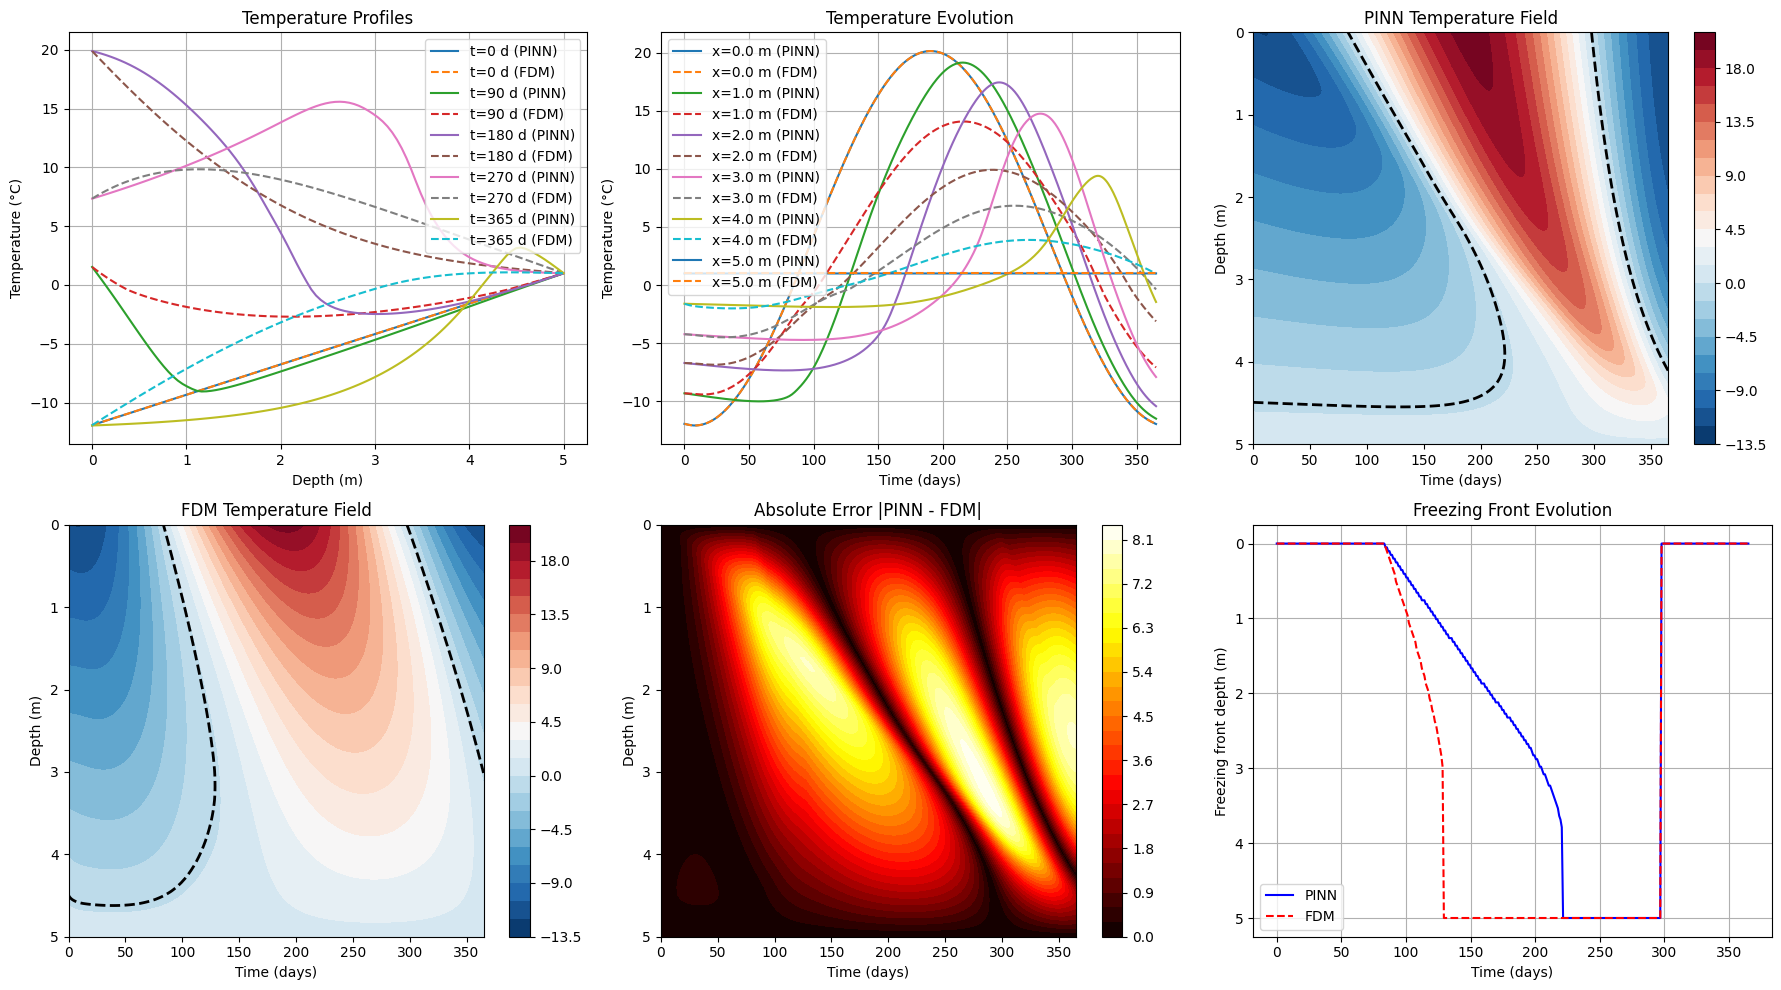

In [92]:
if __name__ == '__main__':
    main()